170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1839s 11us/step


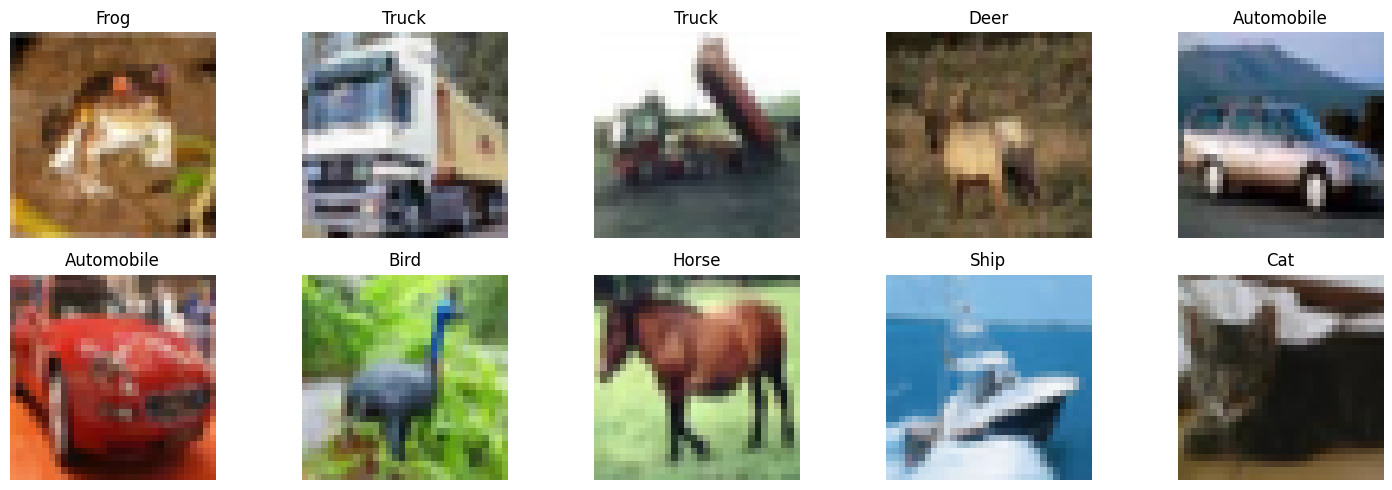

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)

Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [4]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Display 10 sample images
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Print dimensions of training and testing datasets
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("\nTesting images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

In [5]:
# ============================================
# TASK 2: TRANSFER LEARNING USING MOBILENETV2
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input,
    Resizing,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.models import Model


# --------------------------------------------
# 1. Load pretrained MobileNetV2
# --------------------------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)


# --------------------------------------------
# 2. Freeze the convolutional base
# --------------------------------------------

base_model.trainable = False


# --------------------------------------------
# 3. Create model
# --------------------------------------------

# CIFAR-10 input size
inputs = Input(shape=(32, 32, 3))

# Resize images inside the model
x = Resizing(96, 96)(inputs)

# MobileNetV2 expects values in [-1, 1]
# Task 1 images are already in [0, 1]
x = x * 2.0 - 1.0

# Pass through pretrained MobileNetV2
x = base_model(x, training=False)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Dense layer with ReLU
x = Dense(
    128,
    activation="relu"
)(x)

# Output layer with Softmax
outputs = Dense(
    10,
    activation="softmax"
)(x)


# --------------------------------------------
# 4. Create final model
# --------------------------------------------

model = Model(
    inputs=inputs,
    outputs=outputs
)


# --------------------------------------------
# 5. Display model summary
# --------------------------------------------

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# ============================================
# TASK 3: MODEL TRAINING
# ============================================

import tensorflow as tf


# --------------------------------------------
# 1. Convert labels to one-hot encoding
# --------------------------------------------

y_train_onehot = tf.keras.utils.to_categorical(
    y_train,
    num_classes=10
)

y_test_onehot = tf.keras.utils.to_categorical(
    y_test,
    num_classes=10
)


# --------------------------------------------
# 2. Create Training Dataset
# IMPORTANT: Do NOT resize images here
# The model already resizes 32x32 to 96x96
# --------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train_onehot)
)

train_dataset = train_dataset.shuffle(
    10000
)

train_dataset = train_dataset.batch(
    32
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


# --------------------------------------------
# 3. Create Testing Dataset
# IMPORTANT: Do NOT resize images here
# --------------------------------------------

test_dataset = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test_onehot)
)

test_dataset = test_dataset.batch(
    32
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)


# --------------------------------------------
# 4. Compile the Model
# --------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------
# 5. Train the Model
# --------------------------------------------

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.8298 - loss: 0.5000 - val_accuracy: 0.8459 - val_loss: 0.4409
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8758 - loss: 0.3595 - val_accuracy: 0.8620 - val_loss: 0.3910
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8910 - loss: 0.3083 - val_accuracy: 0.8639 - val_loss: 0.3986
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9078 - loss: 0.2620 - val_accuracy: 0.8657 - val_loss: 0.4087
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9208 - loss: 0.2210 - val_accuracy: 0.8650 - val_loss: 0.4427
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9352 - loss: 0.1820 - val_accuracy: 0.8655 - val_loss: 0.4602
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9460 - loss: 0.1512 - val_accuracy: 0.8543 - val_loss: 0.4955
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9564 - 

In [8]:
# ============================================
# TASK 4: FINE TUNING
# ============================================

import tensorflow as tf


# --------------------------------------------
# 1. Store accuracy before fine-tuning
# --------------------------------------------

accuracy_before_finetuning = history.history["val_accuracy"][-1]

print(
    "Validation Accuracy Before Fine-Tuning:",
    round(accuracy_before_finetuning * 100, 2),
    "%"
)


# --------------------------------------------
# 2. Unfreeze the convolutional base
# --------------------------------------------

base_model.trainable = True


# --------------------------------------------
# 3. Freeze all layers except last block
# --------------------------------------------

for layer in base_model.layers:
    layer.trainable = False


# Unfreeze the last convolution block
for layer in base_model.layers[-20:]:
    layer.trainable = True


# --------------------------------------------
# 4. Recompile the model
# --------------------------------------------
# Use smaller learning rate for fine-tuning

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------
# 5. Fine-tune for 10 more epochs
# --------------------------------------------

history_finetune = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)


# --------------------------------------------
# 6. Get accuracy after fine-tuning
# --------------------------------------------

accuracy_after_finetuning = history_finetune.history[
    "val_accuracy"
][-1]


# --------------------------------------------
# 7. Compare accuracies
# --------------------------------------------

print("\n========== ACCURACY COMPARISON ==========")

print(
    "Accuracy Before Fine-Tuning:",
    round(accuracy_before_finetuning * 100, 2),
    "%"
)

print(
    "Accuracy After Fine-Tuning:",
    round(accuracy_after_finetuning * 100, 2),
    "%"
)

print(
    "Improvement:",
    round(
        (accuracy_after_finetuning -
         accuracy_before_finetuning) * 100,
        2
    ),
    "percentage points"
)

Validation Accuracy Before Fine-Tuning: 86.14 %
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.8600 - loss: 0.5579 - val_accuracy: 0.8390 - val_loss: 0.5903
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9247 - loss: 0.2184 - val_accuracy: 0.8563 - val_loss: 0.5894
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9459 - loss: 0.1567 - val_accuracy: 0.8613 - val_loss: 0.5703
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9567 - loss: 0.1233 - val_accuracy: 0.8794 - val_loss: 0.5290
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9643 - loss: 0.1022 - val_accuracy: 0.8736 - val_loss: 0.5874
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9712 - loss: 0.0850 - val_accuracy: 0.8710 - val_loss: 0.5852
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9746 - loss: 0.0708 - val_accuracy: 0.8741 - val_loss: 0.5889
Epoch 8/10
1563/1563 ━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step
========== MODEL EVALUATION ==========

Accuracy: 87.87 %
Precision: 88.12 %
Recall: 87.87 %
F1-Score: 87.88 %

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

    Airplane       0.84      0.93      0.88      1000
  Automobile       0.97      0.91      0.94      1000
        Bird       0.80      0.90      0.85      1000
         Cat       0.78      0.78      0.78      1000
        Deer       0.87      0.87      0.87      1000
         Dog       0.86      0.78      0.82      1000
        Frog       0.91      0.87      0.89      1000
       Horse       0.92      0.92      0.92      1000
        Ship       0.96      0.89      0.92      1000
       Truck       0.91      0.95      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



<Figure size 1000x800 with 0 Axes>

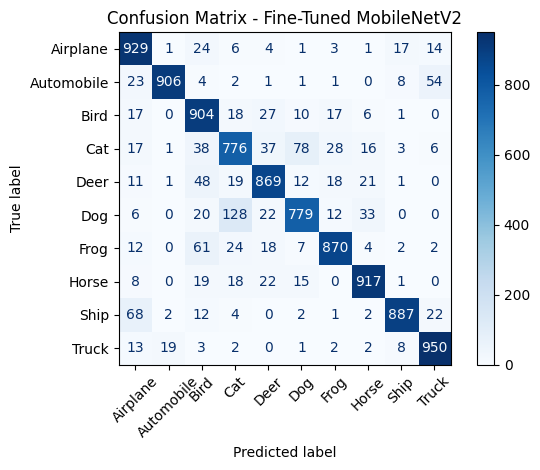

In [9]:
# ============================================
# TASK 5: MODEL EVALUATION
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# --------------------------------------------
# 1. Get predictions from the fine-tuned model
# --------------------------------------------

y_pred_probabilities = model.predict(
    test_dataset
)

# Convert predicted probabilities to class labels
y_pred = np.argmax(
    y_pred_probabilities,
    axis=1
)


# --------------------------------------------
# 2. Get actual class labels
# --------------------------------------------

# Convert one-hot encoded labels to class numbers
y_true = np.argmax(
    y_test_onehot,
    axis=1
)


# --------------------------------------------
# 3. Calculate Accuracy
# --------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)


# --------------------------------------------
# 4. Calculate Precision
# --------------------------------------------

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# --------------------------------------------
# 5. Calculate Recall
# --------------------------------------------

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# --------------------------------------------
# 6. Calculate F1-Score
# --------------------------------------------

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# --------------------------------------------
# 7. Print Evaluation Metrics
# --------------------------------------------

print("========== MODEL EVALUATION ==========\n")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(recall * 100, 2),
    "%"
)

print(
    "F1-Score:",
    round(f1 * 100, 2),
    "%"
)


# --------------------------------------------
# 8. Define CIFAR-10 class names
# --------------------------------------------

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]


# --------------------------------------------
# 9. Print Classification Report
# --------------------------------------------

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


# --------------------------------------------
# 10. Create Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)


# --------------------------------------------
# 11. Display Confusion Matrix
# --------------------------------------------

plt.figure(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Fine-Tuned MobileNetV2")
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# HYPERPARAMETER STUDY
# Compare 10 different hyperparameter settings
# ============================================

import tensorflow as tf
import pandas as pd

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input,
    Resizing,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.models import Model


# ============================================
# 1. CREATE THE MODEL
# ============================================

def create_model(dense_units=128, frozen_layers="All"):

    # Load pretrained MobileNetV2
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(96, 96, 3)
    )


    # ----------------------------------------
    # Freeze all convolutional layers
    # ----------------------------------------

    if frozen_layers == "All":

        base_model.trainable = False


    # ----------------------------------------
    # Partial fine-tuning
    # Freeze earlier layers and unfreeze
    # the last 20 layers
    # ----------------------------------------

    elif frozen_layers == "Partial":

        base_model.trainable = True

        # Freeze all layers
        for layer in base_model.layers:
            layer.trainable = False

        # Unfreeze the last convolution block
        for layer in base_model.layers[-20:]:
            layer.trainable = True


    # ----------------------------------------
    # Input layer for CIFAR-10
    # ----------------------------------------

    inputs = Input(
        shape=(32, 32, 3)
    )


    # ----------------------------------------
    # Resize inside the model
    # ----------------------------------------

    x = Resizing(
        96,
        96
    )(inputs)


    # ----------------------------------------
    # MobileNetV2 preprocessing
    # Convert pixel values from [0,1]
    # to approximately [-1,1]
    # ----------------------------------------

    x = x * 2.0 - 1.0


    # ----------------------------------------
    # Pretrained MobileNetV2
    # ----------------------------------------

    x = base_model(
        x,
        training=False
    )


    # ----------------------------------------
    # Global Average Pooling
    # ----------------------------------------

    x = GlobalAveragePooling2D()(x)


    # ----------------------------------------
    # Dense layer
    # ----------------------------------------

    x = Dense(
        dense_units,
        activation="relu"
    )(x)


    # ----------------------------------------
    # Output layer
    # ----------------------------------------

    outputs = Dense(
        10,
        activation="softmax"
    )(x)


    # ----------------------------------------
    # Create final model
    # ----------------------------------------

    model = Model(
        inputs=inputs,
        outputs=outputs
    )


    return model


# ============================================
# 2. RUN ONE EXPERIMENT
# ============================================

def run_experiment(
    learning_rate,
    batch_size,
    epochs,
    optimizer_name,
    dense_units,
    frozen_layers
):

    # Create a fresh model
    experiment_model = create_model(
        dense_units=dense_units,
        frozen_layers=frozen_layers
    )


    # ----------------------------------------
    # Select optimizer
    # ----------------------------------------

    if optimizer_name == "Adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )


    elif optimizer_name == "SGD":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )


    # ----------------------------------------
    # Compile model
    # ----------------------------------------

    experiment_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )


    # ----------------------------------------
    # Create training dataset
    # ----------------------------------------

    train_ds = tf.data.Dataset.from_tensor_slices(
        (x_train, y_train_onehot)
    )

    train_ds = train_ds.shuffle(
        10000
    )

    train_ds = train_ds.batch(
        batch_size
    )

    train_ds = train_ds.prefetch(
        tf.data.AUTOTUNE
    )


    # ----------------------------------------
    # Create testing dataset
    # ----------------------------------------

    test_ds = tf.data.Dataset.from_tensor_slices(
        (x_test, y_test_onehot)
    )

    test_ds = test_ds.batch(
        batch_size
    )

    test_ds = test_ds.prefetch(
        tf.data.AUTOTUNE
    )


    # ----------------------------------------
    # Train model
    # ----------------------------------------

    history_experiment = experiment_model.fit(
        train_ds,
        epochs=epochs,
        validation_data=test_ds,
        verbose=1
    )


    # ----------------------------------------
    # Get best validation accuracy
    # ----------------------------------------

    best_val_accuracy = max(
        history_experiment.history["val_accuracy"]
    )


    return best_val_accuracy


# ============================================
# 3. DEFINE TOP 10 SETTINGS
# ============================================

experiments = [

    # 1. Baseline
    {
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 2. Lower Learning Rate
    {
        "Learning Rate": 0.0001,
        "Batch Size": 32,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 3. Small Batch Size
    {
        "Learning Rate": 0.001,
        "Batch Size": 16,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 4. Large Batch Size
    {
        "Learning Rate": 0.001,
        "Batch Size": 64,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 5. More Epochs
    {
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 20,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 6. SGD Optimizer
    {
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 10,
        "Optimizer": "SGD",
        "Dense Units": 128,
        "Frozen Layers": "All"
    },


    # 7. More Dense Units
    {
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 256,
        "Frozen Layers": "All"
    },


    # 8. Partial Fine-Tuning
    {
        "Learning Rate": 0.0001,
        "Batch Size": 32,
        "Epochs": 10,
        "Optimizer": "Adam",
        "Dense Units": 128,
        "Frozen Layers": "Partial"
    },


    # 9. Higher Capacity Model
    {
        "Learning Rate": 0.0001,
        "Batch Size": 16,
        "Epochs": 20,
        "Optimizer": "Adam",
        "Dense Units": 256,
        "Frozen Layers": "Partial"
    },


    # 10. Combined Fine-Tuning Setting
    {
        "Learning Rate": 0.0001,
        "Batch Size": 32,
        "Epochs": 20,
        "Optimizer": "Adam",
        "Dense Units": 256,
        "Frozen Layers": "Partial"
    }
]


# ============================================
# 4. RUN ALL 10 EXPERIMENTS
# ============================================

results = []

for i, experiment in enumerate(experiments):

    print("\n" + "=" * 60)

    print(
        "RUNNING EXPERIMENT",
        i + 1,
        "OF",
        len(experiments)
    )

    print(experiment)

    print("=" * 60)


    # Run experiment

    best_accuracy = run_experiment(
        learning_rate=experiment[
            "Learning Rate"
        ],

        batch_size=experiment[
            "Batch Size"
        ],

        epochs=experiment[
            "Epochs"
        ],

        optimizer_name=experiment[
            "Optimizer"
        ],

        dense_units=experiment[
            "Dense Units"
        ],

        frozen_layers=experiment[
            "Frozen Layers"
        ]
    )


    # ----------------------------------------
    # Store experiment result
    # ----------------------------------------

    result = experiment.copy()

    result[
        "Best Validation Accuracy (%)"
    ] = round(
        best_accuracy * 100,
        2
    )

    results.append(
        result
    )


# ============================================
# 5. DISPLAY FINAL RESULTS
# ============================================

results_df = pd.DataFrame(
    results
)


print(
    "\n========== HYPERPARAMETER STUDY RESULTS ==========\n"
)

print(
    results_df
)


# ============================================
# 6. SORT RESULTS BY ACCURACY
# ============================================

results_df = results_df.sort_values(
    by="Best Validation Accuracy (%)",
    ascending=False
)


print(
    "\n========== RANKED RESULTS ==========\n"
)

print(
    results_df
)


# ============================================
# 7. SAVE RESULTS AS CSV
# ============================================

results_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print(
    "\nHyperparameter study completed successfully!"
)

print(
    "Results saved as: hyperparameter_results.csv"
)


RUNNING EXPERIMENT 1 OF 10
{'Learning Rate': 0.001, 'Batch Size': 32, 'Epochs': 10, 'Optimizer': 'Adam', 'Dense Units': 128, 'Frozen Layers': 'All'}
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8306 - loss: 0.4971 - val_accuracy: 0.8557 - val_loss: 0.4272
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8741 - loss: 0.3620 - val_accuracy: 0.8602 - val_loss: 0.4016
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8919 - loss: 0.3071 - val_accuracy: 0.8609 - val_loss: 0.4088
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9075 - loss: 0.2632 - val_accuracy: 0.8607 - val_loss: 0.4218
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9223 - loss: 0.2207 - val_accuracy: 0.8597 - val_loss: 0.4482
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9343 - loss: 0.1861 - val_accuracy: 0.8622 - val_loss: 0.4698
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accu

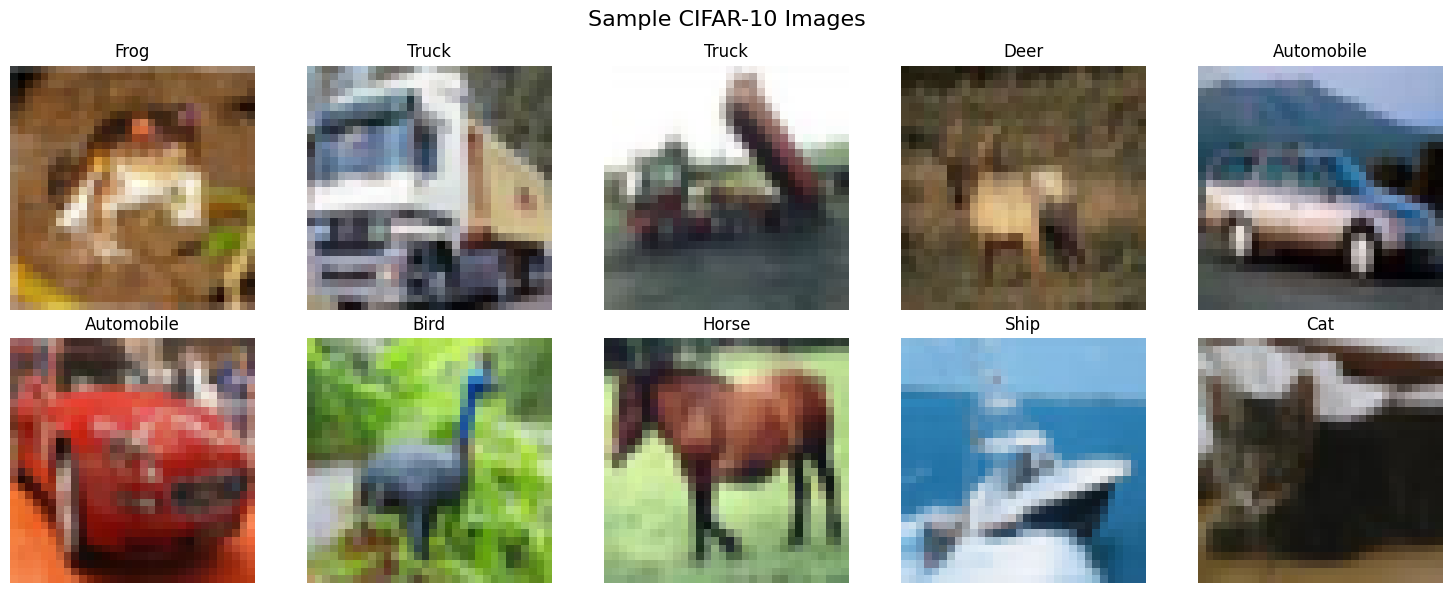

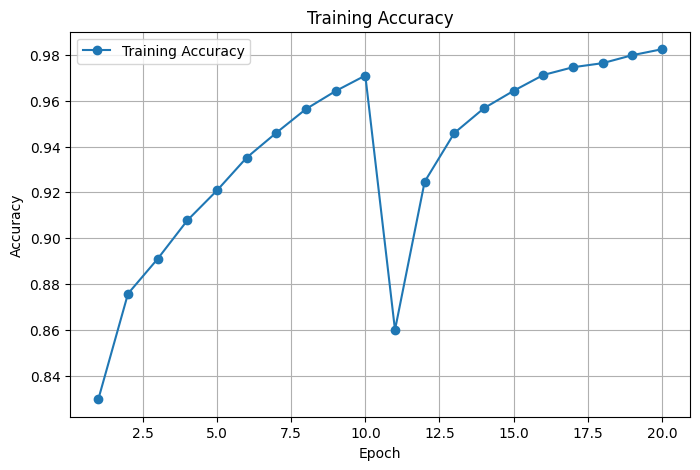

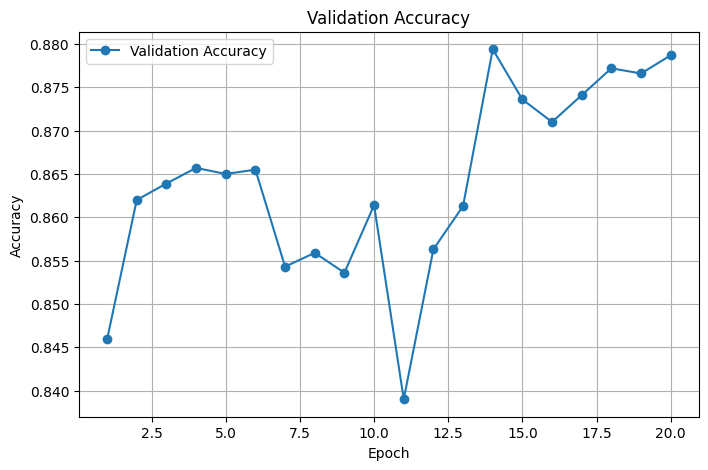

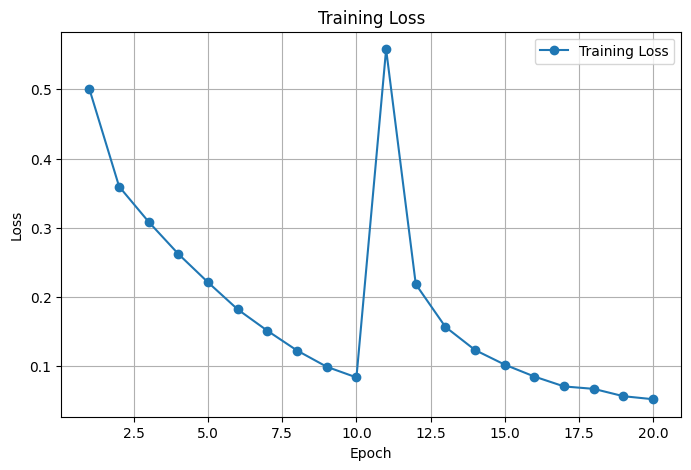

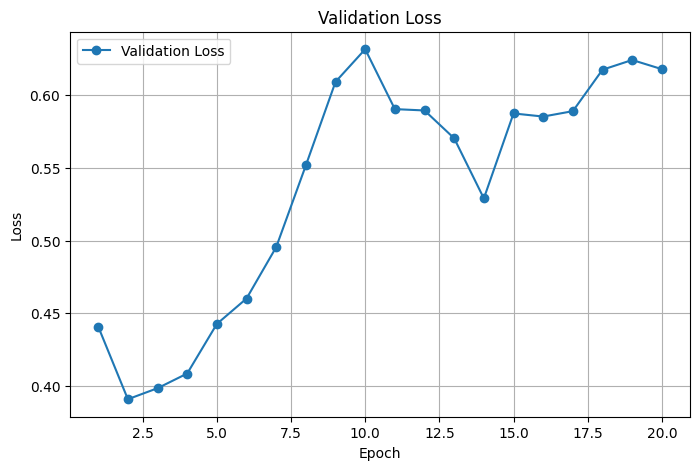

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


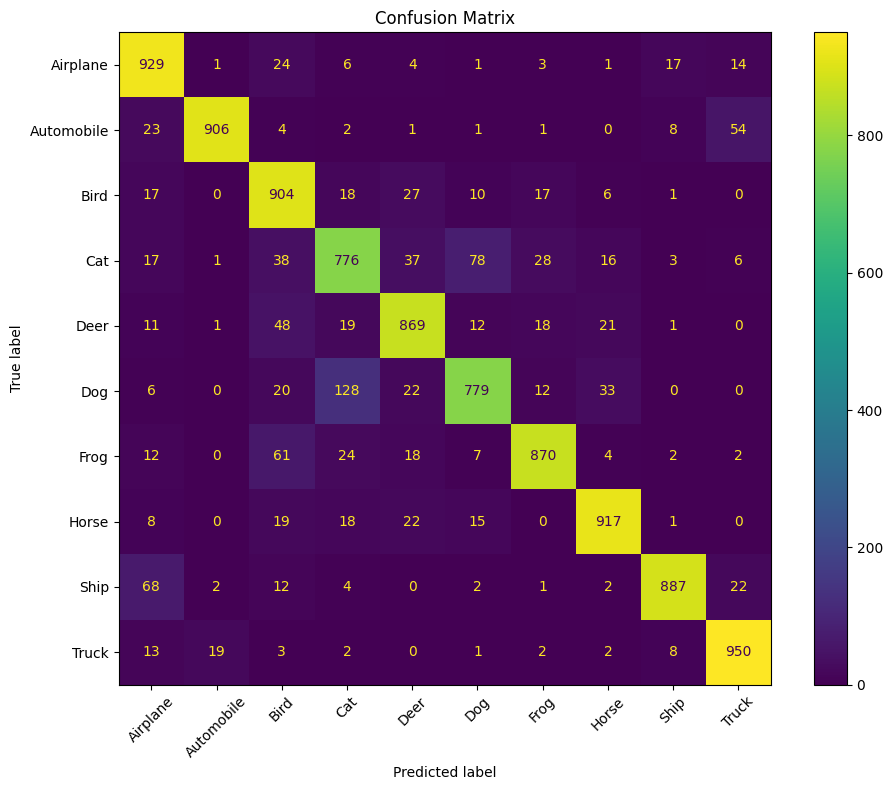

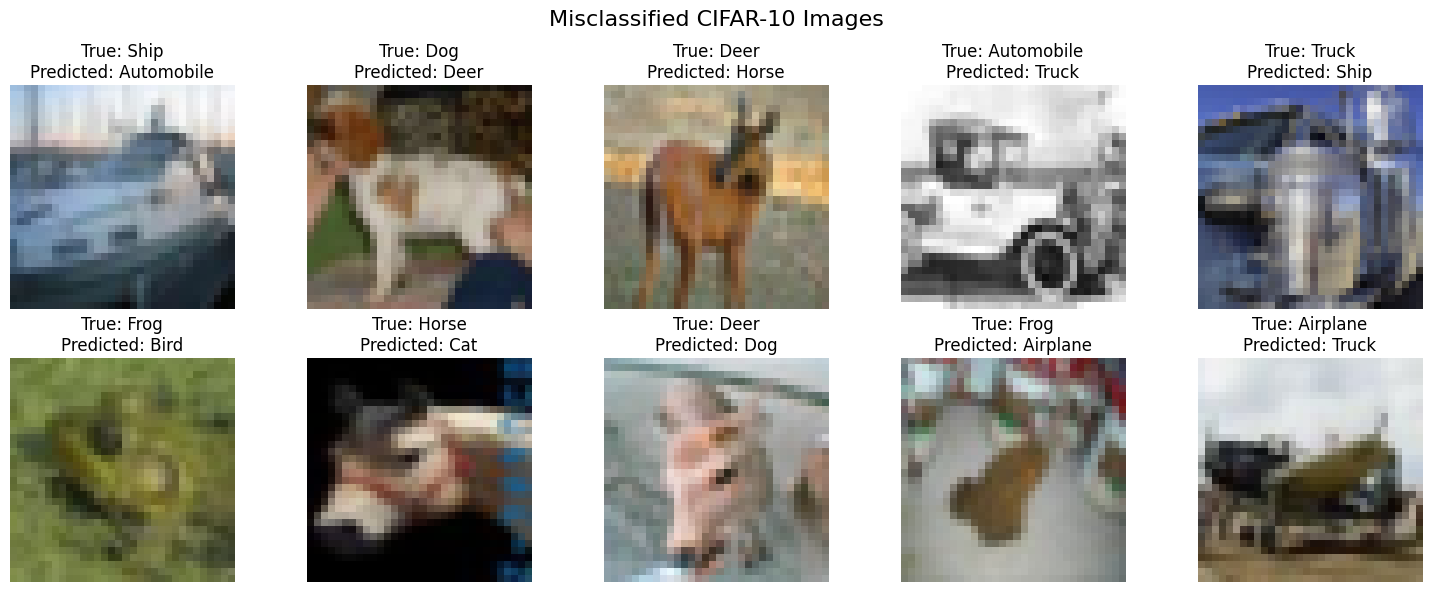

In [11]:
# ============================================
# MANDATORY PLOTS
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================
# CIFAR-10 CLASS NAMES
# ============================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]


# ============================================
# 1. SAMPLE CIFAR-10 IMAGES
# ============================================

plt.figure(figsize=(15, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i])

    # Get class label
    label = int(np.array(y_train[i]).flatten()[0])

    plt.title(
        class_names[label]
    )

    plt.axis("off")


plt.suptitle(
    "Sample CIFAR-10 Images",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================
# COMBINE TASK 3 AND TASK 4 HISTORY
# ============================================

combined_train_accuracy = (
    history.history["accuracy"]
    +
    history_finetune.history["accuracy"]
)

combined_val_accuracy = (
    history.history["val_accuracy"]
    +
    history_finetune.history["val_accuracy"]
)

combined_train_loss = (
    history.history["loss"]
    +
    history_finetune.history["loss"]
)

combined_val_loss = (
    history.history["val_loss"]
    +
    history_finetune.history["val_loss"]
)


total_epochs = range(
    1,
    len(combined_train_accuracy) + 1
)


# ============================================
# 2. TRAINING ACCURACY
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    total_epochs,
    combined_train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.title(
    "Training Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================
# 3. VALIDATION ACCURACY
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    total_epochs,
    combined_val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================
# 4. TRAINING LOSS
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    total_epochs,
    combined_train_loss,
    marker="o",
    label="Training Loss"
)

plt.title(
    "Training Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================
# 5. VALIDATION LOSS
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    total_epochs,
    combined_val_loss,
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================
# 6. CONFUSION MATRIX
# ============================================

# Get predictions from final fine-tuned model
y_pred_probabilities = model.predict(
    test_dataset
)

# Convert probabilities to class labels
y_pred = np.argmax(
    y_pred_probabilities,
    axis=1
)

# Get true class labels
y_true = np.argmax(
    y_test_onehot,
    axis=1
)

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)


# Display confusion matrix
fig, ax = plt.subplots(
    figsize=(10, 8)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================
# 7. MISCLASSIFIED IMAGES
# ============================================

# Find incorrect predictions
misclassified_indices = np.where(
    y_pred != y_true
)[0]


# Display first 10 misclassified images
plt.figure(figsize=(15, 6))

for i, index in enumerate(
    misclassified_indices[:10]
):

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        x_test[index]
    )

    plt.title(
        f"True: {class_names[y_true[index]]}\n"
        f"Predicted: {class_names[y_pred[index]]}"
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Misclassified CIFAR-10 Images",
    fontsize=16
)

plt.tight_layout()

plt.show()

Loading CIFAR-10 dataset...
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)

MobileNetV2 result added successfully.

TRAINING: LeNet-5
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3632 - loss: 1.7668 - val_accuracy: 0.4445 - val_loss: 1.5248
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4721 - loss: 1.4714 - val_accuracy: 0.5017 - val_loss: 1.3901
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5135 - loss: 1.3647 - val_accuracy: 0.5226 - val_loss: 1.3337
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5390 - loss: 1.2981 - val_accuracy: 0.5503 - val_loss: 1.2728
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5599 - loss: 1.2431 - val_accuracy: 0.5490 - val_loss: 1.2525
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5797 - loss: 1.1885 - val_accuracy: 0.5713 - val_loss: 1.2241
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0

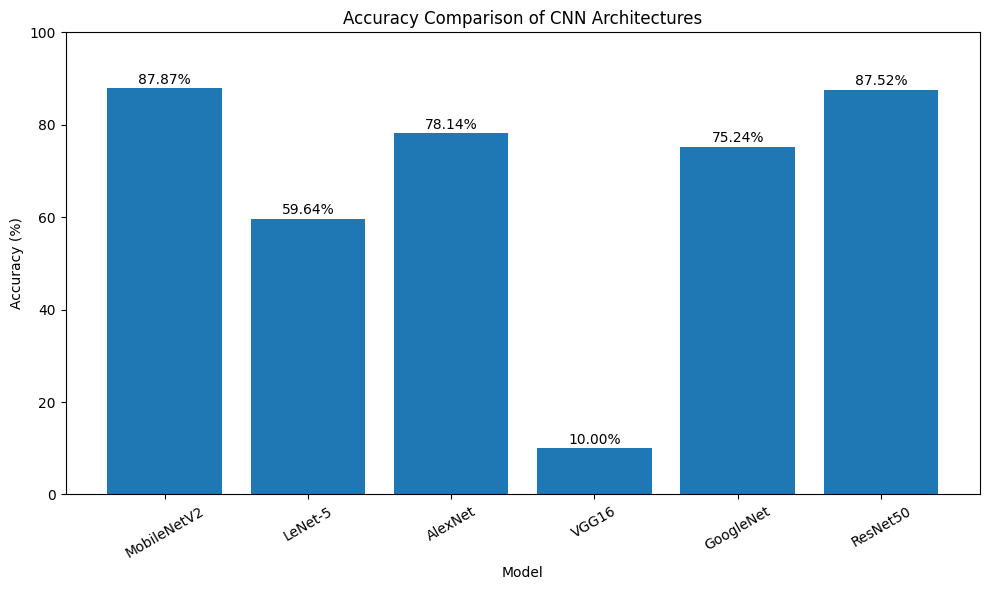

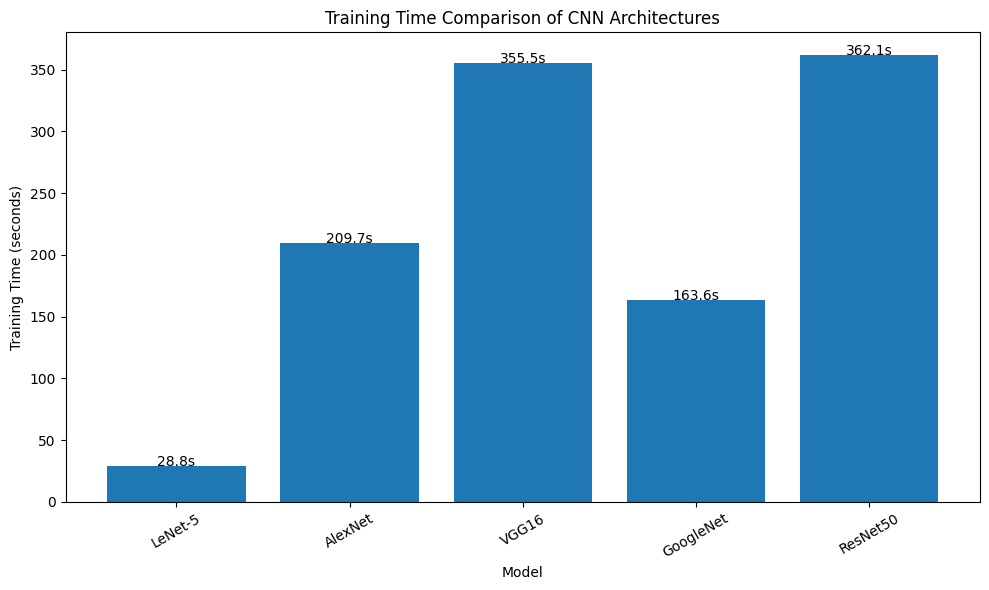

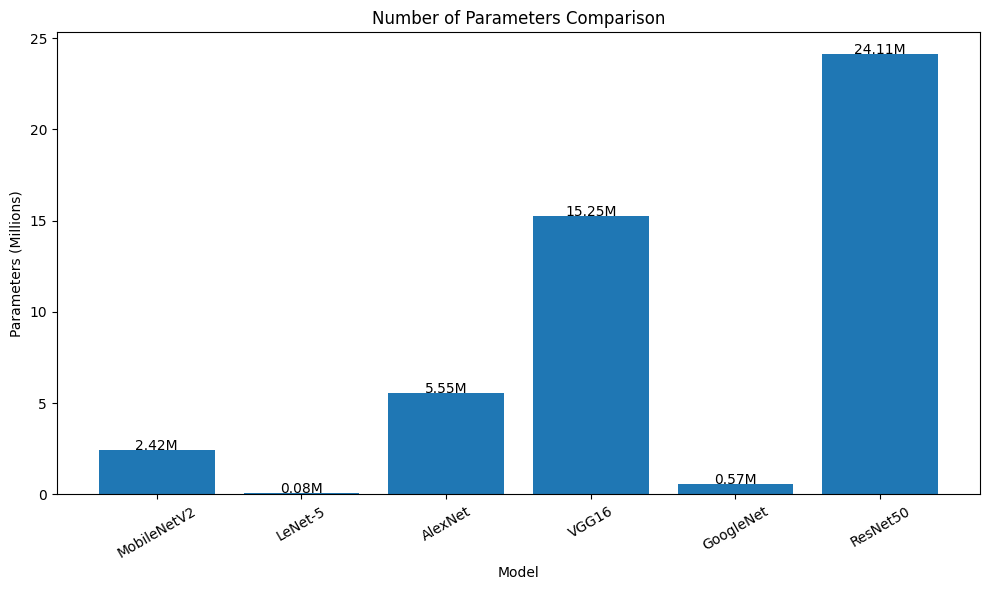



VALUES FOR SECTION 18.2
MobileNetV2 & 2,423,242 & 87.87 & nan \\
LeNet-5 & 83,126 & 59.64 & 28.78 \\
AlexNet & 5,554,698 & 78.14 & 209.71 \\
VGG16 & 15,245,130 & 10.00 & 355.5 \\
GoogleNet & 567,954 & 75.24 & 163.61 \\
ResNet50 & 24,114,826 & 87.52 & 362.11 \\


In [15]:
# ============================================================
# EXTENSION: COMPARISON OF CNN ARCHITECTURES
# LeNet-5, AlexNet, VGG16, GoogleNet, ResNet50
# CIFAR-10
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gc

from tensorflow.keras import layers, models, applications

# ============================================================
# 1. CHECK / LOAD CIFAR-10 DATA
# ============================================================

try:
    X_train
    X_test
    y_train
    y_test
    print("Using existing CIFAR-10 dataset.")
except NameError:
    print("Loading CIFAR-10 dataset...")

    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    y_train = y_train.flatten()
    y_test = y_test.flatten()

# Ensure labels are 1-dimensional
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# ============================================================
# 2. TRAINING FUNCTION
# ============================================================

EPOCHS = 10
BATCH_SIZE = 128

def train_and_evaluate_model(model, model_name, epochs=EPOCHS):
    print("\n" + "=" * 60)
    print("TRAINING:", model_name)
    print("=" * 60)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    training_time = time.time() - start_time

    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    total_parameters = model.count_params()

    result = {
        "Model": model_name,
        "Parameters": int(total_parameters),
        "Accuracy (%)": round(test_accuracy * 100, 2),
        "Training Time (seconds)": round(training_time, 2)
    }

    print("\n" + "-" * 60)
    print(model_name, "RESULTS")
    print("-" * 60)
    print("Total Parameters:", f"{total_parameters:,}")
    print("Testing Accuracy:", f"{test_accuracy * 100:.2f}%")
    print("Training Time:", f"{training_time:.2f} seconds")

    return history, result


# ============================================================
# 3. INITIALIZE RESULTS LIST
# ============================================================

results = []


# ============================================================
# 4. ADD MOBILENETV2 RESULT
# ============================================================
# These values are from YOUR already completed MobileNetV2 run.
# No need to train MobileNetV2 again.
#
# Your output:
# Total Parameters = 2,423,242
# Accuracy = 87.87%
#
# Update training time below if you have measured the exact
# total training time from your notebook.
# ============================================================

mobilenet_result = {
    "Model": "MobileNetV2",
    "Parameters": 2423242,
    "Accuracy (%)": 87.87,
    "Training Time (seconds)": None
}

results.append(mobilenet_result)

print("\nMobileNetV2 result added successfully.")


# ============================================================
# 5. LENET-5
# ============================================================

tf.keras.backend.clear_session()

lenet5 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        6,
        kernel_size=(5, 5),
        activation="relu",
        padding="same"
    ),

    layers.AveragePooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        16,
        kernel_size=(5, 5),
        activation="relu"
    ),

    layers.AveragePooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        120,
        activation="relu"
    ),

    layers.Dense(
        84,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

history_lenet, result_lenet = train_and_evaluate_model(
    lenet5,
    "LeNet-5"
)

results.append(result_lenet)

del lenet5
gc.collect()


# ============================================================
# 6. ALEXNET
# CIFAR-10 ADAPTED VERSION
# ============================================================

tf.keras.backend.clear_session()

alexnet = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        96,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        256,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Conv2D(
        384,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        384,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        256,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        512,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

history_alexnet, result_alexnet = train_and_evaluate_model(
    alexnet,
    "AlexNet"
)

results.append(result_alexnet)

del alexnet
gc.collect()


# ============================================================
# 7. VGG16
# CIFAR-10 ADAPTED VGG16
# ============================================================

tf.keras.backend.clear_session()

def vgg_block(x, filters, conv_layers):
    for _ in range(conv_layers):
        x = layers.Conv2D(
            filters,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(x)

    return x


inputs = layers.Input(shape=(32, 32, 3))

x = vgg_block(inputs, 64, 2)
x = vgg_block(x, 128, 2)
x = vgg_block(x, 256, 3)
x = vgg_block(x, 512, 3)
x = vgg_block(x, 512, 3)

x = layers.Flatten()(x)

x = layers.Dense(
    512,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(
    512,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

vgg16 = models.Model(
    inputs,
    outputs,
    name="VGG16"
)

history_vgg16, result_vgg16 = train_and_evaluate_model(
    vgg16,
    "VGG16"
)

results.append(result_vgg16)

del vgg16
gc.collect()


# ============================================================
# 8. GOOGLENET / INCEPTION-STYLE MODEL
# ============================================================

tf.keras.backend.clear_session()


def inception_module(x, f1, f3_reduce, f3, f5_reduce, f5, pool_proj):

    # 1x1 branch
    branch1 = layers.Conv2D(
        f1,
        kernel_size=(1, 1),
        activation="relu",
        padding="same"
    )(x)

    # 1x1 -> 3x3 branch
    branch2 = layers.Conv2D(
        f3_reduce,
        kernel_size=(1, 1),
        activation="relu",
        padding="same"
    )(x)

    branch2 = layers.Conv2D(
        f3,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(branch2)

    # 1x1 -> 5x5 branch
    branch3 = layers.Conv2D(
        f5_reduce,
        kernel_size=(1, 1),
        activation="relu",
        padding="same"
    )(x)

    branch3 = layers.Conv2D(
        f5,
        kernel_size=(5, 5),
        activation="relu",
        padding="same"
    )(branch3)

    # Pooling branch
    branch4 = layers.MaxPooling2D(
        pool_size=(3, 3),
        strides=1,
        padding="same"
    )(x)

    branch4 = layers.Conv2D(
        pool_proj,
        kernel_size=(1, 1),
        activation="relu",
        padding="same"
    )(branch4)

    output = layers.Concatenate()([
        branch1,
        branch2,
        branch3,
        branch4
    ])

    return output


inputs = layers.Input(shape=(32, 32, 3))

x = layers.Conv2D(
    64,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
)(inputs)

x = layers.MaxPooling2D(
    pool_size=(2, 2)
)(x)

x = inception_module(
    x,
    32,
    32,
    64,
    8,
    16,
    16
)

x = inception_module(
    x,
    64,
    64,
    96,
    16,
    32,
    32
)

x = layers.MaxPooling2D(
    pool_size=(2, 2)
)(x)

x = inception_module(
    x,
    96,
    64,
    128,
    16,
    32,
    32
)

x = inception_module(
    x,
    128,
    96,
    192,
    32,
    64,
    64
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

googlenet = models.Model(
    inputs,
    outputs,
    name="GoogleNet"
)

history_googlenet, result_googlenet = train_and_evaluate_model(
    googlenet,
    "GoogleNet"
)

results.append(result_googlenet)

del googlenet
gc.collect()


# ============================================================
# 9. RESNET50
# TRANSFER LEARNING WITH CIFAR-10
# ============================================================

tf.keras.backend.clear_session()

# Resize CIFAR-10 images from 32x32 to 96x96
inputs = layers.Input(
    shape=(32, 32, 3)
)

x = layers.Resizing(
    96,
    96
)(inputs)

# ResNet50 preprocessing
x = applications.resnet50.preprocess_input(
    x * 255.0
)

# Load pretrained ResNet50
resnet_base = applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(96, 96, 3)
)

# Freeze pretrained layers
resnet_base.trainable = False

x = resnet_base(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    10,
    activation="softmax"
)(x)

resnet50 = models.Model(
    inputs,
    outputs,
    name="ResNet50"
)

history_resnet50, result_resnet50 = train_and_evaluate_model(
    resnet50,
    "ResNet50"
)

results.append(result_resnet50)


# ============================================================
# 10. CREATE COMPARISON DATAFRAME
# ============================================================

comparison_df = pd.DataFrame(results)

# Format parameters for display
comparison_display = comparison_df.copy()

comparison_display["Parameters"] = comparison_display[
    "Parameters"
].apply(lambda x: f"{x:,}")

print("\n")
print("=" * 80)
print("CNN ARCHITECTURE COMPARISON")
print("=" * 80)

print(
    comparison_display.to_string(
        index=False
    )
)


# ============================================================
# 11. SAVE RESULTS TO CSV
# ============================================================

comparison_df.to_csv(
    "cnn_architecture_comparison.csv",
    index=False
)

print("\nResults saved as:")
print("cnn_architecture_comparison.csv")


# ============================================================
# 12. ACCURACY COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title(
    "Accuracy Comparison of CNN Architectures"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    100
)

for i, value in enumerate(
    comparison_df["Accuracy (%)"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 13. TRAINING TIME COMPARISON PLOT
# ============================================================

# Remove MobileNetV2 from this plot if its exact total
# training time has not been entered.

time_df = comparison_df.dropna(
    subset=["Training Time (seconds)"]
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    time_df["Model"],
    time_df["Training Time (seconds)"]
)

plt.title(
    "Training Time Comparison of CNN Architectures"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.xticks(
    rotation=30
)

for i, value in enumerate(
    time_df["Training Time (seconds)"]
):
    plt.text(
        i,
        value,
        f"{value:.1f}s",
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 14. PARAMETERS COMPARISON PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["Parameters"] / 1_000_000
)

plt.title(
    "Number of Parameters Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Parameters (Millions)"
)

plt.xticks(
    rotation=30
)

for i, value in enumerate(
    comparison_df["Parameters"] / 1_000_000
):
    plt.text(
        i,
        value,
        f"{value:.2f}M",
        ha="center"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 15. FINAL LATEX VALUES
# ============================================================

print("\n")
print("=" * 80)
print("VALUES FOR SECTION 18.2")
print("=" * 80)

for _, row in comparison_df.iterrows():

    print(
        f"{row['Model']} & "
        f"{row['Parameters']:,} & "
        f"{row['Accuracy (%)']:.2f} & "
        f"{row['Training Time (seconds)']} \\\\"
    )